Tópicos Avançados em IA

Rayssa Coelho(BEC): Dataset Dermatology

1. Configuração e Importações

In [102]:
%pip install -r requirements.txt

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 258.1 kB/s eta 0:00:36
   -- ------------------------------------- 0.5/9.6 MB 258.1 kB/s eta 0:00:36
   -- ------------------------------------- 0.5/9.6 MB 258.1 kB/s eta 0:00:36
   -- ------------------------------------- 0.5/9.6 MB 258.1 kB/s eta 0:00:3

In [103]:
import pandas as pd                                             # manipular dados (dataframe)
import numpy as np                                              # cálculos
import wandb                                                    # rastrear, visualizar e gerenciar experimentos de ML
import kagglehub                                                # acessar datasets do Kaggle
import shutil                                                   # serve para mexer com arquivos e pastas
import os                                                       # para lidar com caminhos de arquivos e diretórios
import seaborn as sns                                           # gráficos
import random                                                   # para gerar números aleatórios
import matplotlib.pyplot as plt                                 # gráficos
import joblib                                                   # para salvar e carregar modelos
import torch                                                    # para trabalhar com tensores e deep learning
import torch.nn as nn                                           # para construir redes neurais
import torch.optim as optim                                     # para otimizar os pesos da rede neural
import statsmodels.api as sm                                    # para análise estatística

from torch.utils.data import DataLoader, TensorDataset          # para criar dataloaders a partir de tensores
from pyparsing import col                                       # para lidar com colunas em parsing de texto
from dotenv import load_dotenv                                  # para carregar variáveis de ambiente de um arquivo .env
from sklearn.model_selection import train_test_split            # para dividir os dados em treino e teste
from sklearn.impute import SimpleImputer                        # para tratar valores faltantes
from sklearn.feature_selection import mutual_info_regression    # para calcular a importância das features usando mutual information
from sklearn.ensemble import RandomForestRegressor              # modelo de regressão baseado em árvores
from sklearn.linear_model import LinearRegression               # modelo de regressão linear
from sklearn.metrics import mean_squared_error                  # para calcular o erro do modelo
from sklearn.ensemble import RandomForestRegressor              # modelo de regressão baseado em árvores
from sklearn.linear_model import LinearRegression               # modelo de regressão linear
from sklearn.metrics import mean_squared_error                  # para calcular o erro do modelo
from sklearn.preprocessing import MinMaxScaler                  # para normalizar os dados
from sklearn.feature_selection import mutual_info_classif       # para calcular a importância das features usando mutual information
from sklearn.ensemble import RandomForestClassifier             # modelo de classificação baseado em árvores
from sklearn.preprocessing import StandardScaler                # para padronizar os dados
from sklearn.feature_selection import SelectKBest, f_classif    # para selecionar as melhores features usando o teste f_classif
from sklearn.pipeline import Pipeline                           # para criar um pipeline de pré-processamento e modelagem
from sklearn.linear_model import LogisticRegression             # modelo de regressão logística para classificação
from sklearn.inspection import permutation_importance           # para calcular a importância das features usando permutation importance
from statsmodels.stats.outliers_influence import variance_inflation_factor  # para calcular o VIF (Variance Inflation Factor) e detectar multicolinearidade

print("Todas as bibliotecas importadas com sucesso.")


Todas as bibliotecas importadas com sucesso.


In [56]:
# Configurar semente para reprodutibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

config = {
    "data": {
        "target_col": "class",
        "test_size": 0.2,
        "random_state": 42,
        "imputation_strategy": "median",
        "missing_threshold": 0.5
    },
    "model": {
        "k_features": 10,
        "max_iter": 500 
    }
}

2. Adicionando o Dataset

In [ ]:
path = kagglehub.dataset_download("olcaybolat1/dermatology-dataset-classification") 
print("Path to dataset files:", path)

Path to dataset files: C:\Users\rayco\.cache\kagglehub\datasets\olcaybolat1\dermatology-dataset-classification\versions\5


In [ ]:
# carrega as variáveis de ambiente do arquivo .env
load_dotenv()

# caminho que o kagglehub retornou
source_path = path  

# destino dentro do seu projeto
dest_path = os.path.join(os.getcwd(), "data")

# copia tudo pra pasta data
shutil.copytree(source_path, dest_path, dirs_exist_ok=True)

print("Dataset copiado para:", dest_path)

Dataset copiado para: c:\Users\rayco\Desktop\atividades\aulas_ia\learning_ai\projeto_avaliacao\data


In [13]:
df_raw = pd.read_csv( # lê o arquivo CSV
     "data/dermatology_database_1.csv",
    low_memory=False # evita avisos de tipos de dados mistos
)
print(f"Shape: {df_raw.shape}") # mostra o número de linhas e colunas
print(f"Columns: {list(df_raw.columns[:5])}...") # mostra os nomes das primeiras 5 colunas
df_raw.head() # mostra as primeiras 5 linhas do dataframe

Shape: (366, 35)
Columns: ['erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon']...


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_infiltrate,PNL_infiltrate,fibrosis_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_rete_ridges,elongation_rete_ridges,thinning_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,1,0,0,1,0,1,2,0,2,2,2,2,2,1,0,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,0,1,0,0,0,1,2,0,2,0,0,0,0,0,2,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,0,0,0,3,0,0,2,0,3,2,2,2,2,0,0,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,0,1,0,0,0,1,2,0,0,0,0,0,0,0,2,2,3,2,3,0,0,2,3,45,3


In [14]:
df_raw.describe() # mostra estatísticas básicas das colunas numéricas

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,family_history,melanin_incontinence,eosinophils_infiltrate,PNL_infiltrate,fibrosis_papillary_dermis,exocytosis,acanthosis,hyperkeratosis,parakeratosis,clubbing_rete_ridges,elongation_rete_ridges,thinning_suprapapillary_epidermis,spongiform_pustule,munro_microabcess,focal_hypergranulosis,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,0.125683,0.404372,0.139344,0.546448,0.336066,1.368852,1.956284,0.527322,1.289617,0.663934,0.991803,0.633880,0.295082,0.363388,0.393443,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,0.331946,0.869818,0.411790,0.815451,0.853139,1.104418,0.712512,0.757116,0.917562,1.056829,1.162161,1.034924,0.670578,0.759721,0.849406,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,1.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000


Nota-se que a coluna Age não apareceu, pois não apresenta apenas números, ou seja, tem valores faltantes identificados com "?"

3. Login no W&B e Criação Artefato

In [ ]:
API_KEY = os.getenv("WANDB_API_KEY") # pega a chave da API do W&B do arquivo .env
wandb.login(key=API_KEY) 

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\rayco\_netrc
wandb: Currently logged in as: raycoelho (raycoelho-ufrn) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [16]:
# Inicializa um novo run no W&B para esta etapa de carregamento dos dados
wandb.init(
    project="mlops-project-dermatology", # nome do projeto no W&B
    job_type="load_raw", # tipo do job (pode ser "load_raw", "preprocess", "train", etc.)
    name="load_raw" # nome do run (pode ser "load_raw", "preprocess", "train", etc.
)

# Cria um novo artifact para o dataset bruto
artifact = wandb.Artifact( # cria um novo artifact
    name="raw_data", # artifact name (versioned automatically
    type="dataset", # tipo do artifact (pode ser "dataset", "model", "code", etc.)
    description="Dermatology raw dataset from Kaggle"
)
temp_path = "temp_raw.csv" # caminho temporário para salvar o CSV do dataframe
df_raw.to_csv(temp_path, index=False) # salva o dataframe como CSV sem o índice
artifact.add_file(temp_path) # adiciona o arquivo CSV ao artifact

# Log the artifact to W&B
wandb.log_artifact(artifact) # faz o upload do artifact para o W&B

# Log summary statistics visible on the W&B dashboard
wandb.summary["rows"] = len(df_raw) # número de linhas
wandb.summary["columns"] = list(df_raw.columns) # lista de colunas (pode ser truncada se for muito longa)
wandb.finish() # finaliza o run atual no W&B

print("Raw data artifact saved to W&B.")

rows,366


Raw data artifact saved to W&B.


Obs: O arquivo temporário (temp_raw.csv) é criado porque o método wandb.Artifact.add_file() espera um caminho para um arquivo no sistema de arquivos local. O df_raw é um objeto pandas.DataFrame que existe apenas na memória. Para que o Weights & Biases possa rastrear e versionar esse DataFrame como um artefato, ele precisa primeiro ser salvo em um arquivo. Criar um arquivo temporário é uma prática comum para fazer isso sem sobrecarregar o diretório de trabalho com arquivos intermediários permanentes.

4. Análise Exploratória dos Dados Brutos

Text(0.5, 1.0, 'Distribution of Classes')

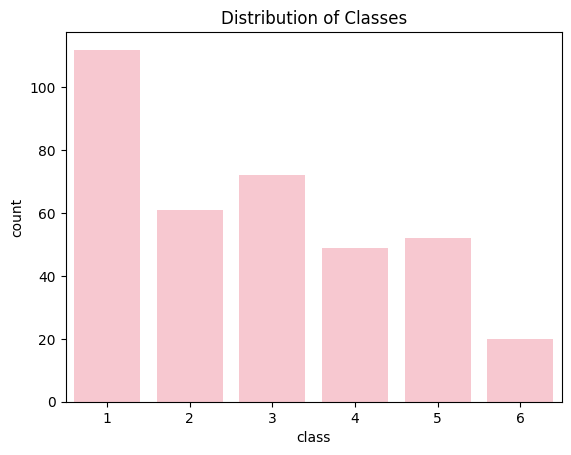

In [ ]:
#Gráfico de barras para a distribuição das classes
sns.countplot(x=df_raw['class'], color="pink") # mostra a distribuição das classes (doenças) no dataset usando um gráfico de barras
plt.title("Distribution of Classes") # título do gráfico

Text(0.5, 0.98, 'Histograms of Numerical Features')

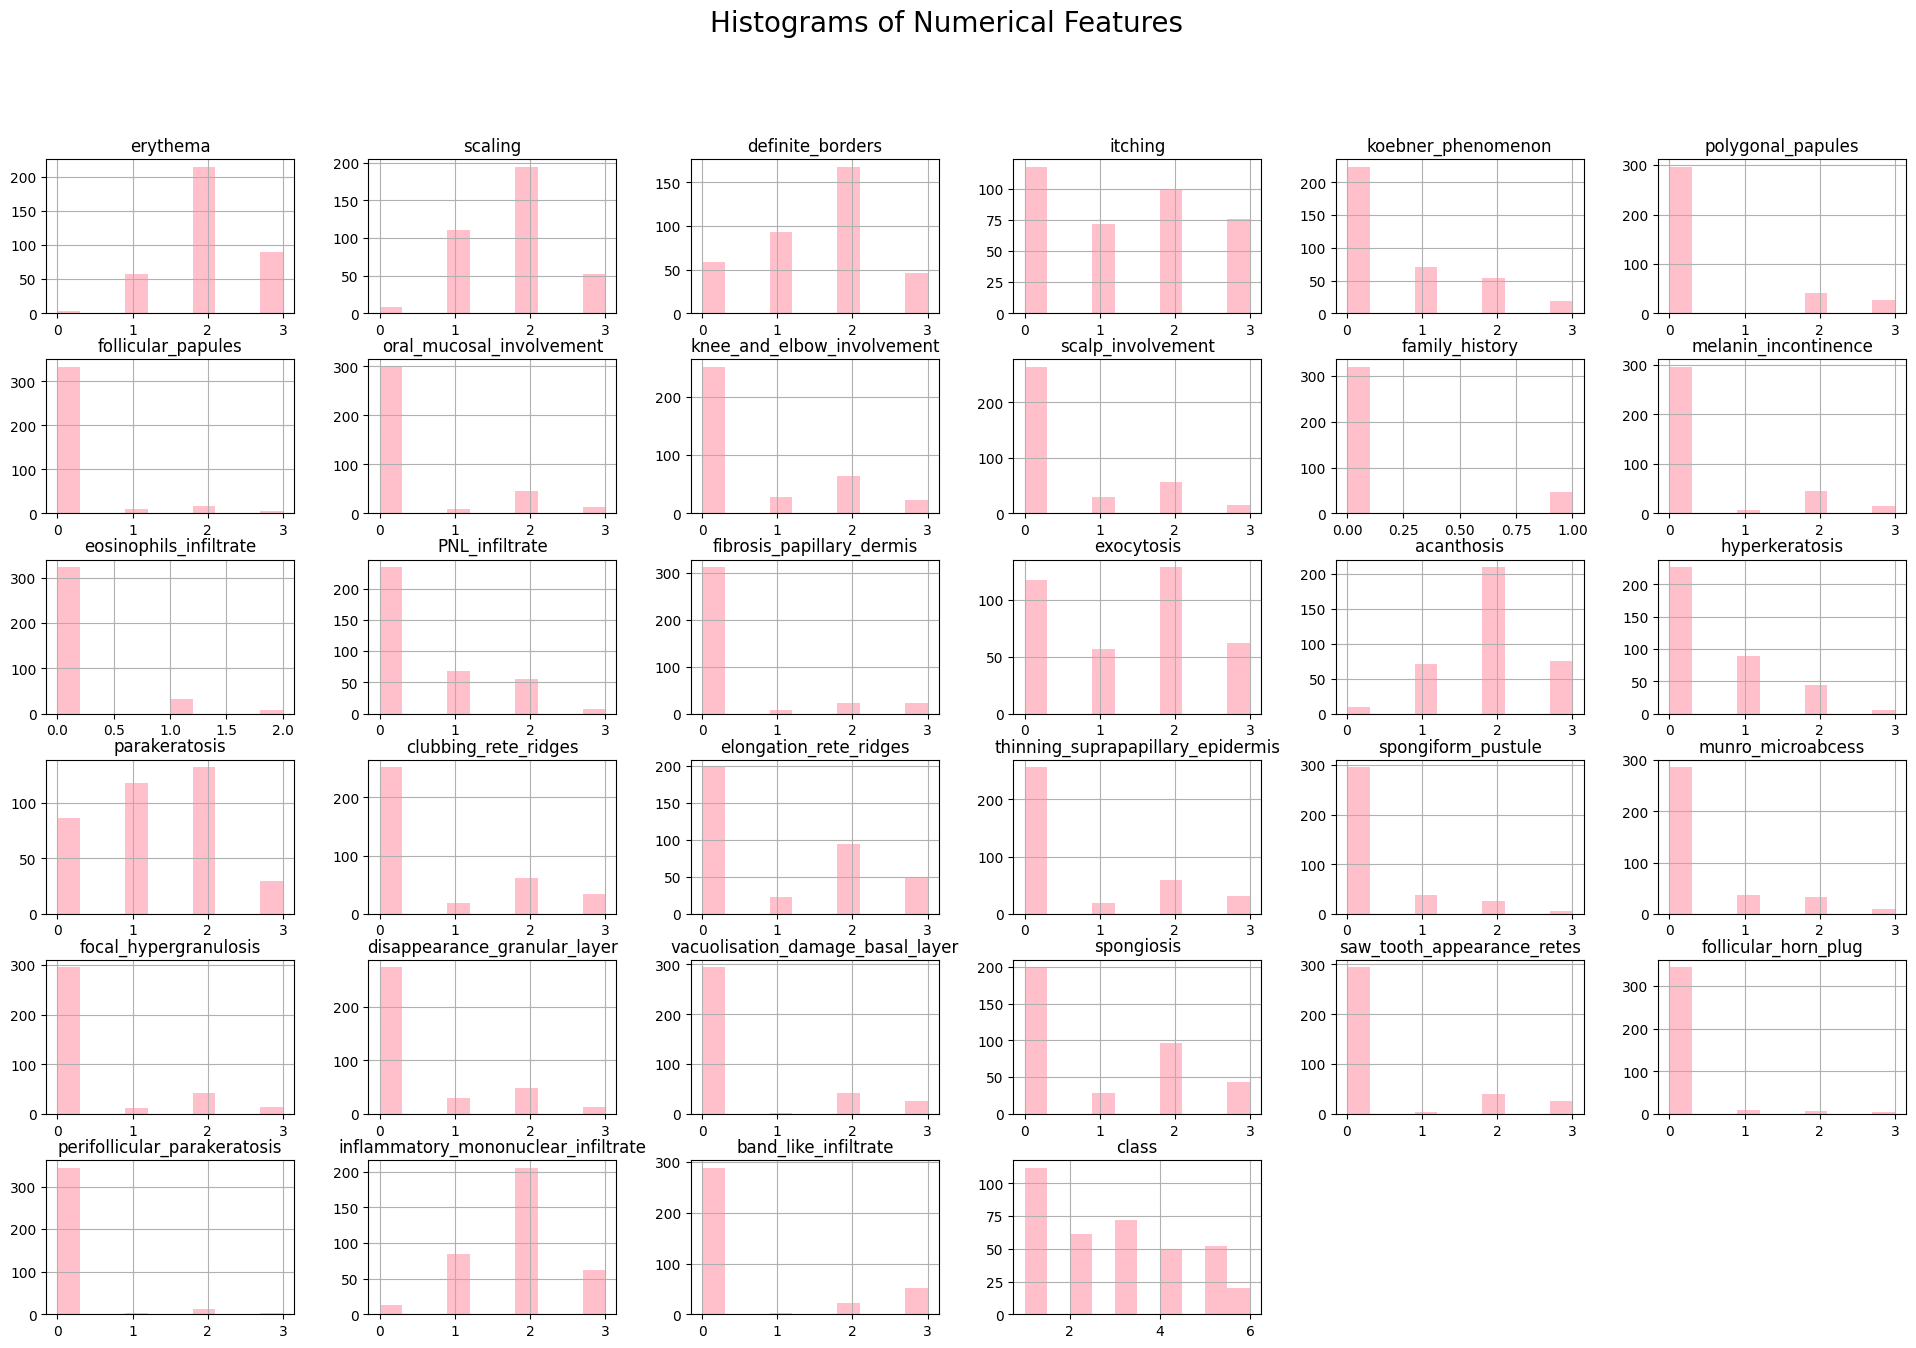

In [18]:
#Histogramas para colunas numéricas
df_raw.hist(figsize=(24,15), color="pink") # mostra histogramas para todas as colunas numéricas do dataframe, com um tamanho de figura grande para melhor visualização
plt.suptitle("Histograms of Numerical Features", fontsize=20) # título geral para os histogramas

5. Limpeza de Dados

Text(0, 0.5, 'Age')

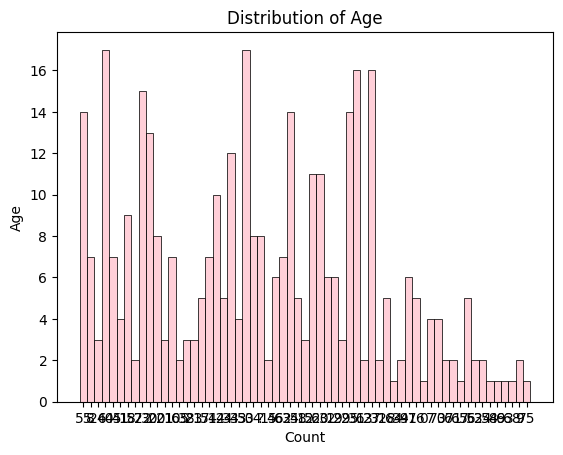

In [19]:
sns.histplot(x=df_raw['age'], color="pink") # mostra a distribuição das classes (doenças) no dataset usando um gráfico de barras
plt.title("Distribution of Age") # título do gráfico
plt.xlabel("Count") # rótulo do eixo x
plt.ylabel("Age") # rótulo do eixo y

Como visto na análise anterior o atributo que precisa de correção vai ser a coluna "Age"

In [ ]:
# Remoção de duplicatas e tratamento de valores faltantes

# CORREÇÃO ESSENCIAL: troca '?' por NaN antes de tudo
df_raw['age'] = df_raw['age'].replace('?', np.nan) # substitui os valores '?' por NaN para que possam ser tratados como valores faltantes
df_raw['age'] = pd.to_numeric(df_raw['age'])  # converte para número

def remove_duplicates(df): # remove linhas duplicadas do dataframe
    before = len(df)        # salva número original de linhas
    df = df.drop_duplicates() # remove todas as linhas duplicadas do dataframe
    print(f"Removed {before - len(df)} duplicates") # imprime quantas linhas foram removidas
    return df # retorna o dataframe sem duplicatas

def handle_missing_values(df, strategy=config["data"]["imputation_strategy"], threshold=config["data"]["missing_threshold"]): # trata valores faltantes
    missing_frac = df.isnull().median() # calcula a fração de valores faltantes por coluna
    cols_to_drop = missing_frac[missing_frac > threshold].index.tolist() # identifica colunas com mais de 50% de valores faltantes
    df = df.drop(columns=cols_to_drop) # remove essas colunas do dataframe
    print(f"Dropped columns: {cols_to_drop}") # imprime quais colunas foram removidas 
    numeric_cols = df.select_dtypes(include=[np.number]).columns # seleciona apenas as colunas numéricas
    imputer = SimpleImputer(strategy=strategy) # cria um imputer para preencher os valores faltantes usando a estratégia escolhida (mediana)
    df[numeric_cols] = imputer.fit_transform(df[numeric_cols]) # preenche os valores faltantes nas colunas numéricas usando a estratégia escolhida (média, mediana, etc.)
    cat_cols = df.select_dtypes(include=['object']).columns # seleciona apenas as colunas do tipo objeto
    df[cat_cols] = df[cat_cols].fillna('missing') # preenche os valores faltantes com 'missing'
    return df

#executando
df_clean = remove_duplicates(df_raw) # remove linhas duplicadas
df_clean = handle_missing_values(df_clean, strategy=config["data"]["imputation_strategy"], threshold=config["data"]["missing_threshold"]) # trata valores faltantes
print(f"Cleaned dataset shape: {df_clean.shape}") # mostra o número de linhas e colunas do dataset limpo

# confirma que não sobrou nulo
print(f"Nulos restantes: {df_clean.isnull().sum().sum()}")

Removed 0 duplicates
Dropped columns: []
Cleaned dataset shape: (366, 35)
Nulos restantes: 0


Text(0, 0.5, 'Count')

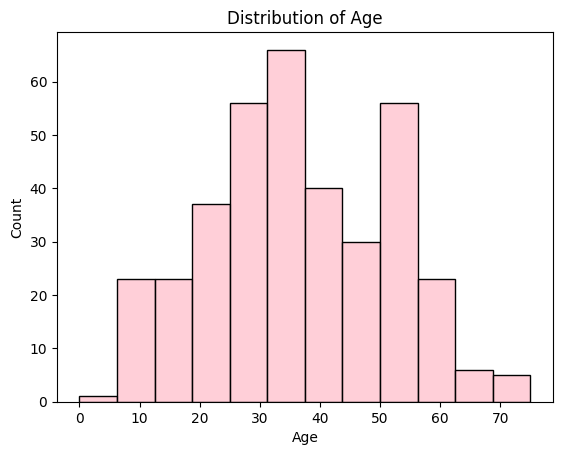

In [21]:
# Gráfico de barras para a distribuição das Idades Limpos
sns.histplot(x=df_clean['age'], color="pink") # mostra a distribuição das classes (doenças) no dataset usando um gráfico de barras
plt.title("Distribution of Age") # título do gráfico
plt.xlabel("Age") # rótulo do eixo x
plt.ylabel("Count") # rótulo do eixo y

In [22]:
wandb.init(project="mlops-project-dermatology", job_type="clean_data", name="clean_data") #inicia um novo run no w&b
artifact = wandb.Artifact("clean_data", type="dataset") # novo artifact para o dataset limpo
temp_clean = "temp_clean.csv" # caminho temporário para salvar o CSV do dataframe limpo
df_clean.to_csv(temp_clean, index=False) #salva o dataframe em um csv e impede que o indice seja salvo como coluna
artifact.add_file(temp_clean) # adiciona o arquivo CSV do dataframe limpo ao artifact
wandb.log_artifact(artifact) # faz o upload do artifact para o W&B
wandb.summary["clean_rows"] = len(df_clean) # adiciona ao resumo do W&B o número de linhas do dataset limpo
wandb.finish() # finaliza o run atual no W&B
print("Cleaned data artifact saved to W&B.")

clean_rows,366


Cleaned data artifact saved to W&B.


Text(0, 0.5, 'Count')

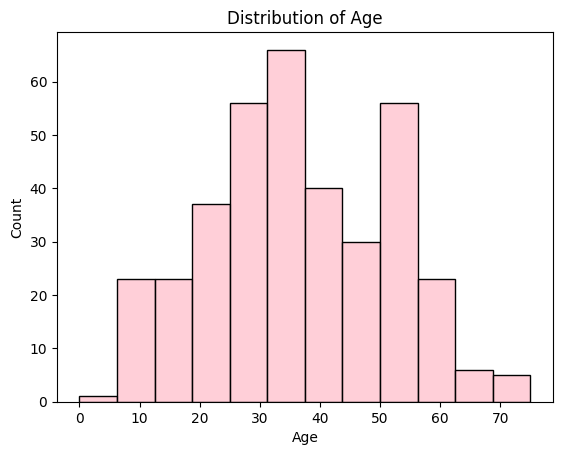

In [23]:
sns.histplot(x=df_clean['age'], color="pink") # mostra a distribuição das classes (doenças) no dataset usando um gráfico de barras
plt.title("Distribution of Age") # título do gráfico
plt.xlabel("Age") # rótulo do eixo x
plt.ylabel("Count") # rótulo do eixo y

In [ ]:
# Tratamento de outliers

def detect_and_treat_outliers_iqr(df_clean, columns, strategy='capping', fator=1.5): # função para detectar e tratar outliers usando o método do intervalo interquartil (IQR)
    # Detecta e trata outliers via IQR.
    # Estratégias: 'capping' | 'mediana' | 'remover', serve para substituir os outliers pelos limites ou pela mediana, ou remover as linhas com outliers
    df_out = df_clean.copy() # para não modificar o original

    for col in columns:
        Q1 = df_out[col].quantile(0.25) # primeiro quartil
        Q3 = df_out[col].quantile(0.75) # terceiro quartil
        IQR = Q3 - Q1 # intervalo interquartil
        li = Q1 - fator * IQR   # limite inferior
        ls = Q3 + fator * IQR   # limite superior

        outliers = ((df_out[col] < li) | (df_out[col] > ls)).sum() # conta quantos outliers existem nessa coluna comparando com os limites se são menores que o limite inferior ou maiores que o limite superior
        print(f"[{col}] Q1={Q1:.1f} | Q3={Q3:.1f} | Limites: [{li:.1f}, {ls:.1f}] | Outliers: {outliers}") # imprime os quartis, limites e número de outliers encontrados
        
        if strategy == 'capping': # substitui os outliers pelos limites
            df_out[col] = df_out[col].clip(lower=li, upper=ls)   # substitui pelos limites

        elif strategy == 'median': # substitui os outliers pela mediana
            mediana = df_out[col].median()
            df_out[col] = df_out[col].where((df_out[col] >= li) & (df_out[col] <= ls), mediana) # substitui os outliers pela mediana usando where para manter os valores dentro dos limites e substituir os outliers

        elif strategy == 'remove': # remove as linhas com outliers
            df_out = df_out[(df_out[col] >= li) & (df_out[col] <= ls)] # mantém apenas as linhas onde os valores estão dentro dos limites, removendo as linhas com outliers

    return df_out
   

# ── executa ───────────────────────────────────────────────────
# só 'age' tem escala contínua; as demais são ordinais (0-3)
colunas_alvo = ['age'] # define quais colunas serão tratadas para outliers (apenas 'age' nesse caso, pois as outras são ordinais com poucos valores possíveis)

df_out = detect_and_treat_outliers_iqr(df_clean, columns=colunas_alvo, strategy='capping') # trata os outliers usando o método do intervalo interquartil (IQR) e a estratégia de capping (substituir pelos limites)

print(f"\nShape após tratamento: {df_clean.shape}") # mostra o número de linhas e colunas do dataset após o tratamento de outliers
print(f"Age — min: {df_clean['age'].min():.0f} | max: {df_clean['age'].max():.0f}") # mostra o valor mínimo e máximo da coluna 'age' após o tratamento de outliers para confirmar que os valores extremos foram tratados
       


[age] Q1=25.0 | Q3=48.0 | Limites: [-9.5, 82.5] | Outliers: 0

Shape após tratamento: (366, 35)
Age — min: 0 | max: 75


Text(0, 0.5, 'Count')

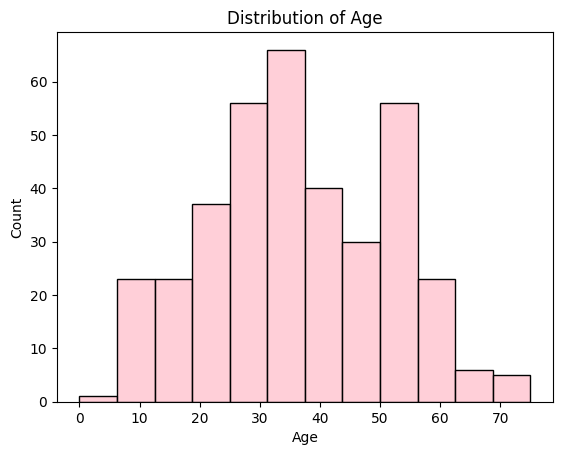

In [25]:
sns.histplot(x=df_out['age'], color="pink") # mostra a distribuição das classes (doenças) no dataset usando um gráfico de barras
plt.title("Distribution of Age") # título do gráfico
plt.xlabel("Age") # rótulo do eixo x
plt.ylabel("Count") # rótulo do eixo y

# 6. Normalização / Padronização

Serve para analisar as escalas.
As categorias estão em uma escala de 0 a 3
Target não mexe
Coluna Age com escala de 0 a 85

In [ ]:

# ── separa target antes de tudo ──────────────────────────
X = df_out.drop(columns=[config["data"]["target_col"]]) # separa as features (todas as colunas exceto 'class') e salva em X
y = df_out[config["data"]["target_col"]] # separa a coluna 'class' como target e salva em y

# ── aplica MinMaxScaler ──────────────────────────────────
scaler = MinMaxScaler() # cria um objeto MinMaxScaler para normalizar os dados, transformando os valores para uma escala entre 0 e 1
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns) # aplica o scaler aos dados de X e cria um novo dataframe com os valores normalizados, mantendo os mesmos nomes de colunas

# ── comparação antes × depois ────────────────────────────
print("ANTES da normalização:")
print(X[['age', 'itching', 'scaling']].describe().round(2)) # mostra estatísticas básicas para as colunas 'age', 'itching' e 'scaling' antes da normalização, arredondando os valores para 2 casas decimais

print("\nDEPOIS da normalização:")
print(X_scaled[['age', 'itching', 'scaling']].describe().round(2)) # mostra estatísticas básicas para as colunas 'age', 'itching' e 'scaling' depois da normalização, arredondando os valores para 2 casas decimais, confirmando que os valores foram transformados para uma escala entre 0 e 1

ANTES da normalização:
          age  itching  scaling
count  366.00   366.00    366.0
mean    36.27     1.37      1.8
std     15.16     1.14      0.7
min      0.00     0.00      0.0
25%     25.00     0.00      1.0
50%     35.00     1.00      2.0
75%     48.00     2.00      2.0
max     75.00     3.00      3.0

DEPOIS da normalização:
          age  itching  scaling
count  366.00   366.00   366.00
mean     0.48     0.46     0.60
std      0.20     0.38     0.23
min      0.00     0.00     0.00
25%      0.33     0.00     0.33
50%      0.47     0.33     0.67
75%      0.64     0.67     0.67
max      1.00     1.00     1.00


In [27]:
wandb.init(project="mlops-project-dermatology", job_type="scaled_data", name="scaled_data") #inicia um novo run no w&b
artifact = wandb.Artifact("scaled_data", type="dataset") # novo artifact para o dataset limpo
df_stand = X_scaled.copy() # cria um novo dataframe df_stand a partir do X_scaled para adicionar a coluna de classe de volta antes de salvar o artifact
df_stand['class'] = y.values # adiciona a coluna 'class' de volta ao dataframe df_stand para que o dataset normalizado tenha tanto as features quanto a target antes de salvar o artifact
temp_stand = "temp_scaled.csv" # caminho temporário para salvar o CSV do dataframe limpo
df_stand.to_csv(temp_stand, index=False) #salva o dataframe em um csv e impede que o indice seja salvo como coluna
artifact.add_file(temp_stand) # adiciona o arquivo CSV do dataframe limpo ao artifact
wandb.log_artifact(artifact) # faz o upload do artifact para o W&B
#wandb.summary["clean_rows"] = len(df_c) # adiciona ao resumo do W&B o número de linhas do dataset limpo
wandb.finish() # finaliza o run atual no W&B
print("Scaled data artifact saved to W&B.")

Scaled data artifact saved to W&B.


# 7. Features Selection

7.1 Método 1: Correlação de Pearson

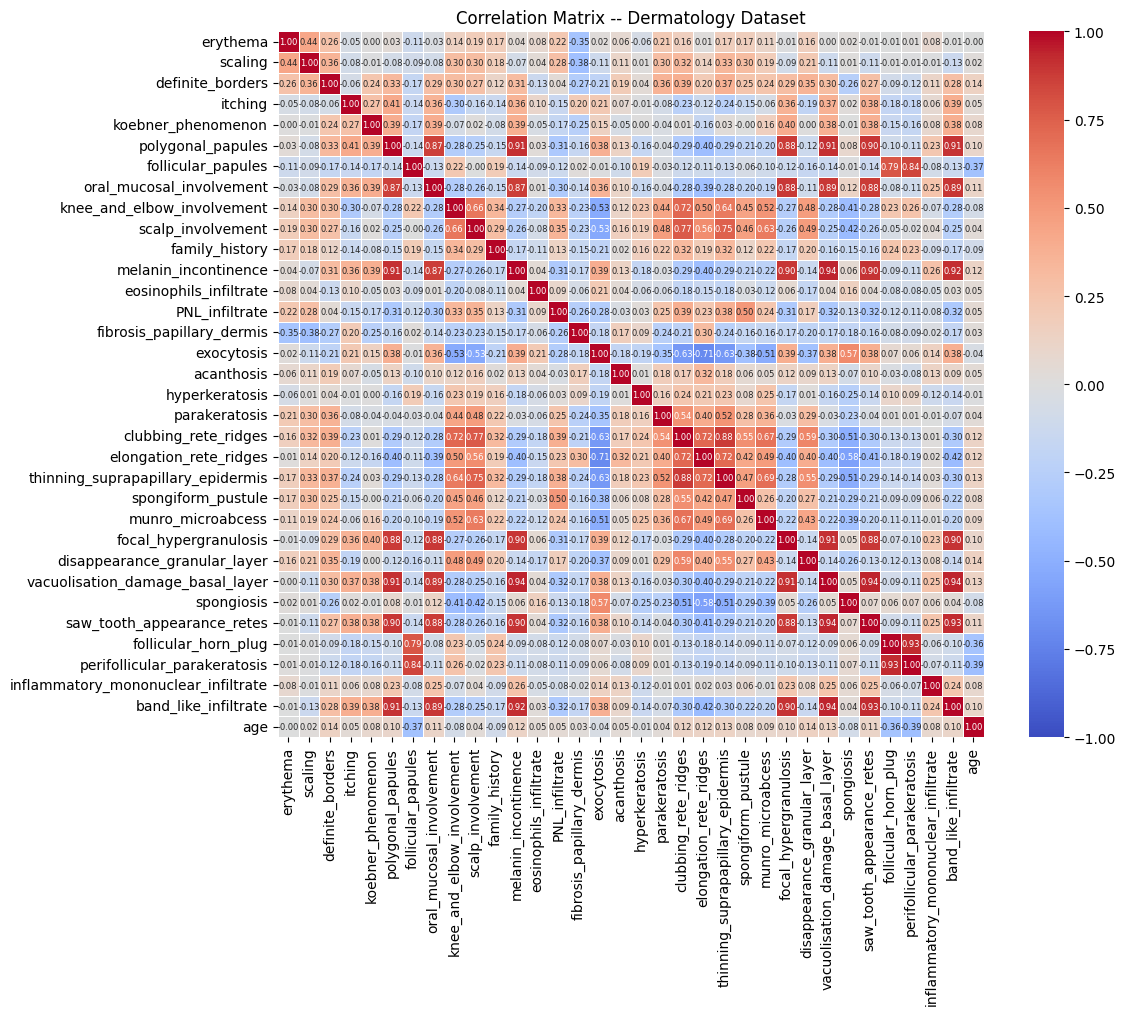

Top 10 features by absolute correlation:
thinning_suprapapillary_epidermis    0.684864
clubbing_rete_ridges                 0.668781
PNL_infiltrate                       0.550195
scalp_involvement                    0.533208
fibrosis_papillary_dermis            0.526976
munro_microabcess                    0.520995
follicular_papules                   0.477813
scaling                              0.468688
perifollicular_parakeratosis         0.457025
spongiform_pustule                   0.449407
dtype: float64


In [106]:
corr_matrix = df_out.drop(columns=[config["data"]["target_col"]]).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, square=True,
            annot_kws={"size": 6})
plt.title('Correlation Matrix -- Dermatology Dataset')
plt.tight_layout()
corr_fig_path = "correlation_matrix.png"
plt.savefig(corr_fig_path, dpi=150)
plt.show()

# ── Ajuste aqui: guardar como corr_series (com .abs()) ────────
corr_series = df_out.drop(columns=[config["data"]["target_col"]]) \
                    .corrwith(df_out[config["data"]["target_col"]]) \
                    .abs() \
                    .sort_values(ascending=False)

print("Top 10 features by absolute correlation:")
print(corr_series.head(10))
# A partir daqui segue normalmente para MI, RF e combinação

In [107]:
# Log to W&B as an image artifact
wandb.init(project="mlops-regression-feature-selection", job_type="eda", name="correlation_matrix")
wandb.log({"correlation_matrix": wandb.Image(corr_fig_path)})
wandb.finish()
print("Correlation matrix image saved and logged to W&B.")

Correlation matrix image saved and logged to W&B.


7.2 Método 2: Mutual Information

In [76]:
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print("Top 10 features by Mutual Information:")
print(mi_series.head(10))

Top 10 features by Mutual Information:
elongation_rete_ridges               0.578766
clubbing_rete_ridges                 0.568074
thinning_suprapapillary_epidermis    0.534654
saw_tooth_appearance_retes           0.503324
melanin_incontinence                 0.499348
band_like_infiltrate                 0.491631
focal_hypergranulosis                0.478665
vacuolisation_damage_basal_layer     0.462895
oral_mucosal_involvement             0.415473
polygonal_papules                    0.411888
dtype: float64


7.3 Método 3: Random Forest

In [87]:
rf = RandomForestClassifier(n_estimators=100, random_state=config["data"]["random_state"])
rf.fit(X, y)
rf_series = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 10 features by Random Forest Importance:")
print(rf_series.head(10))

Top 10 features by Random Forest Importance:
thinning_suprapapillary_epidermis    0.085159
fibrosis_papillary_dermis            0.083784
clubbing_rete_ridges                 0.083688
elongation_rete_ridges               0.064522
koebner_phenomenon                   0.063152
spongiosis                           0.048175
saw_tooth_appearance_retes           0.039732
vacuolisation_damage_basal_layer     0.038646
PNL_infiltrate                       0.035923
band_like_infiltrate                 0.035742
dtype: float64


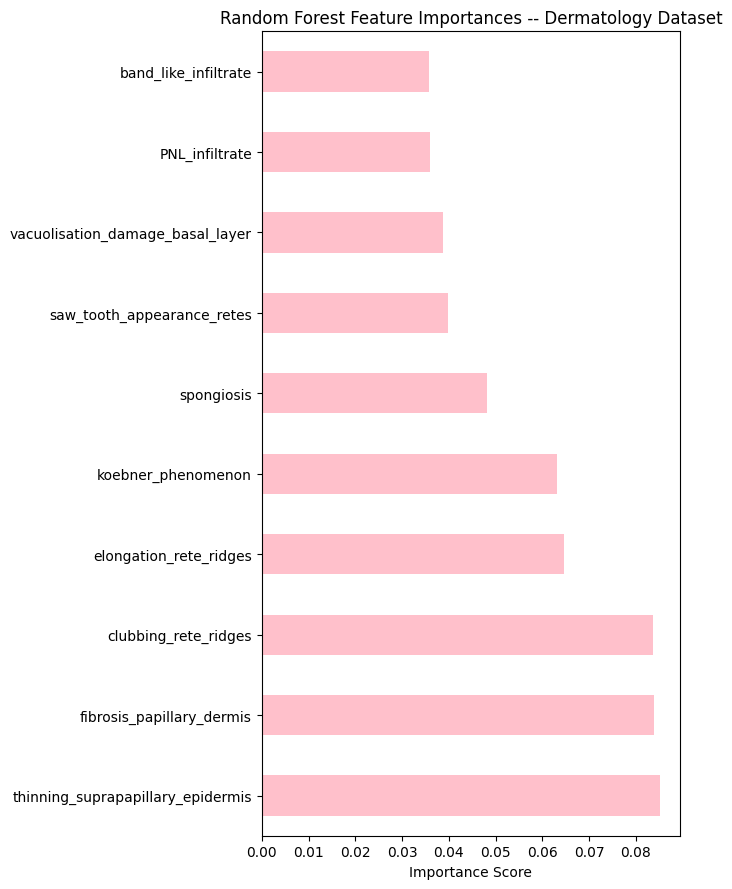

In [88]:
plt.figure(figsize=(7, 9))  
rf_series.head(10).plot(kind='barh', color='pink')
plt.title('Random Forest Feature Importances -- Dermatology Dataset')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [109]:
wandb.init(project="mlops-regression-feature-selection", job_type="eda", name="rf_feature_importance")
wandb.log({"rf_feature_importance": wandb.Image(plt.gcf())}) # loga o gráfico atual (gcf = get current figure) como imagem no W&B
wandb.finish()
print("Random Forest feature importance image logged to W&B.")
# Log to W&B as a graphic artifact

Random Forest feature importance image logged to W&B.


<Figure size 640x480 with 0 Axes>

In [89]:
def normalize(s):
    """Normaliza uma Series para escala 0-1 (Min-Max)"""
    return (s - s.min()) / (s.max() - s.min())

corr_norm = normalize(corr_series)
mi_norm   = normalize(mi_series)
rf_norm   = normalize(rf_series)

# Score final = média dos 3 métodos normalizados
combined        = (corr_norm + mi_norm + rf_norm) / 3
combined_sorted = combined.sort_values(ascending=False)

print("TOP 15 FEATURES — SCORE COMBINADO")
print(combined_sorted.head(15).round(3))

TOP 15 FEATURES — SCORE COMBINADO
clubbing_rete_ridges                 0.980
thinning_suprapapillary_epidermis    0.975
fibrosis_papillary_dermis            0.803
elongation_rete_ridges               0.754
PNL_infiltrate                       0.586
scalp_involvement                    0.521
knee_and_elbow_involvement           0.510
spongiosis                           0.504
munro_microabcess                    0.497
exocytosis                           0.488
saw_tooth_appearance_retes           0.463
band_like_infiltrate                 0.438
perifollicular_parakeratosis         0.438
vacuolisation_damage_basal_layer     0.433
koebner_phenomenon                   0.432
dtype: float64


7.4 Tabela Comparativa

In [90]:
ranking_df = pd.DataFrame({
    'Correlacao'    : corr_norm,
    'Mutual_Info'   : mi_norm,
    'Random_Forest' : rf_norm,
    'Score_Final'   : combined
}).sort_values('Score_Final', ascending=False)

print("\nTABELA COMPARATIVA COMPLETA (scores normalizados 0 a 1):")
print(ranking_df.round(3).to_string())


TABELA COMPARATIVA COMPLETA (scores normalizados 0 a 1):
                                     Correlacao  Mutual_Info  Random_Forest  Score_Final
clubbing_rete_ridges                      0.976        0.982          0.982        0.980
thinning_suprapapillary_epidermis         1.000        0.924          1.000        0.975
fibrosis_papillary_dermis                 0.762        0.663          0.984        0.803
elongation_rete_ridges                    0.508        1.000          0.754        0.754
PNL_infiltrate                            0.797        0.548          0.413        0.586
scalp_involvement                         0.772        0.599          0.192        0.521
knee_and_elbow_involvement                0.546        0.693          0.290        0.510
spongiosis                                0.290        0.664          0.559        0.504
munro_microabcess                         0.753        0.481          0.257        0.497
exocytosis                                0.396     

7.5 VIF

In [115]:
def calculate_vif(df_features):
    """Calcula o VIF para cada feature do dataframe."""
    vif_data = pd.DataFrame()
    vif_data["feature"] = df_features.columns
    vif_data["VIF"] = [
        variance_inflation_factor(df_features.values, i)
        for i in range(df_features.shape[1])
    ]
    return vif_data.sort_values("VIF", ascending=False)


In [116]:
# Pegar as top 15 pelo score combinado para analisar VIF
top15_features = combined_sorted.head(15).index.tolist()
X_top15        = X[top15_features]

vif_df             = calculate_vif(X_top15)
high_vif_features  = vif_df[vif_df['VIF'] > 10]['feature'].tolist()

print(f"\nVIF calculado para as top 15 features:")
print(vif_df.to_string(index=False))
print(f"\nFeatures com VIF > 10 (serão removidas): {high_vif_features}")


VIF calculado para as top 15 features:
                          feature       VIF
 vacuolisation_damage_basal_layer 14.283817
             band_like_infiltrate 12.760680
       saw_tooth_appearance_retes 12.454022
             clubbing_rete_ridges  9.878832
thinning_suprapapillary_epidermis  8.469940
           elongation_rete_ridges  8.144676
       knee_and_elbow_involvement  4.228713
                       exocytosis  4.198537
                scalp_involvement  3.813594
                munro_microabcess  2.782592
                       spongiosis  2.764818
        fibrosis_papillary_dermis  2.607361
               koebner_phenomenon  1.973728
                   PNL_infiltrate  1.868945
     perifollicular_parakeratosis  1.559091

Features com VIF > 10 (serão removidas): ['vacuolisation_damage_basal_layer', 'band_like_infiltrate', 'saw_tooth_appearance_retes']


7.6 Candidatos Finais

In [119]:
candidates     = combined_sorted.head(10).index.tolist()
final_features = [f for f in candidates if f not in high_vif_features]

print("\n" + "="*55)
print("FEATURES FINAIS SELECIONADAS PARA A MLP")
print("="*55)
for i, f in enumerate(final_features, 1):
    print(f"  {i:2d}. {f}  (score: {combined_sorted[f]:.3f})")
print(f"\nTotal: {len(final_features)} features")


FEATURES FINAIS SELECIONADAS PARA A MLP
   1. clubbing_rete_ridges  (score: 0.980)
   2. thinning_suprapapillary_epidermis  (score: 0.975)
   3. fibrosis_papillary_dermis  (score: 0.803)
   4. elongation_rete_ridges  (score: 0.754)
   5. PNL_infiltrate  (score: 0.586)
   6. scalp_involvement  (score: 0.521)
   7. knee_and_elbow_involvement  (score: 0.510)
   8. spongiosis  (score: 0.504)
   9. munro_microabcess  (score: 0.497)
  10. exocytosis  (score: 0.488)

Total: 10 features


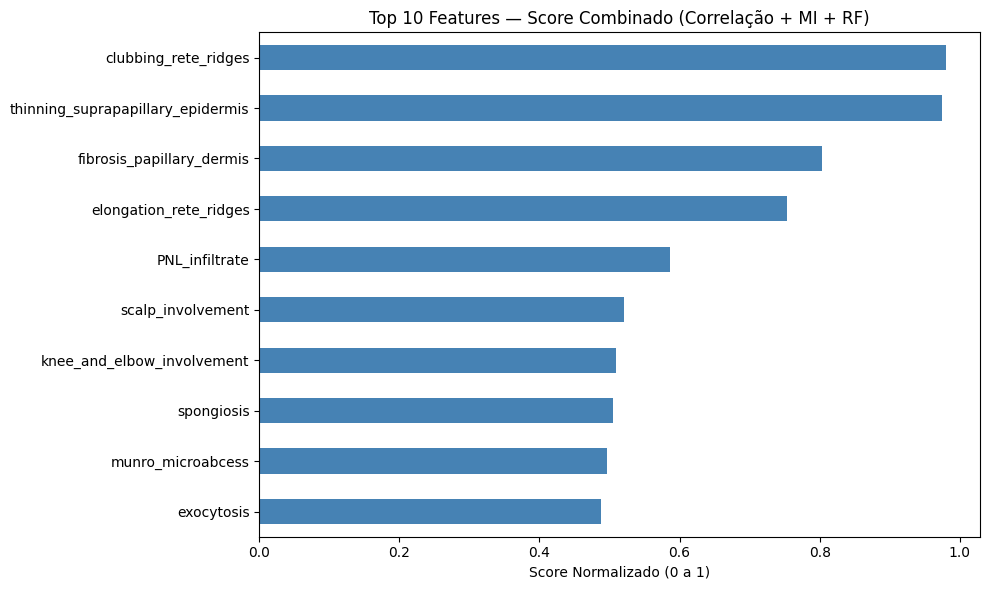

In [120]:
plt.figure(figsize=(10, 6))
combined_sorted.head(10).sort_values().plot(
    kind='barh', color='steelblue'
)
plt.title('Top 10 Features — Score Combinado (Correlação + MI + RF)')
plt.xlabel('Score Normalizado (0 a 1)')
plt.tight_layout()
plt.savefig("feature_ranking.png", dpi=150)
plt.show()

8. Train / Test Splits

In [79]:
X = df_out.drop(columns=[config["data"]["target_col"]]) # separa as features (todas as colunas exceto 'class') e salva em X
y = df_out[config["data"]["target_col"]] # separa a coluna 'class' como target e salva em y
#y_one_hot = pd.get_dummies(y, prefix='col').astype(int)

X_train, X_test, y_train, y_test = train_test_split(   # divide os dados em conjuntos de treino e teste, mantendo a proporção das classes (stratify=y) e usando uma semente fixa para reprodutibilidade (random_state=42)
    X, # features
    y, # target
    test_size=config["data"]["test_size"], # 20% dos dados para teste 
    random_state=config["data"]["random_state"], # para garantir que a divisão  seja a mesma toda vez que rodar o código, facilitando a comparação de resultados
    stratify=y # mantém a proporção das classes em ambos os conjuntos de treino e teste, o que é importante para evitar viés se as classes estiverem desbalanceadas
)

print(X_train.shape) # mostra o número de linhas e colunas do conjunto de treino
print(X_test.shape) # mostra o número de linhas e colunas do conjunto de teste

print(y_train.shape) # mostra o número de linhas e colunas do conjunto de treino
print(y_test.shape) # mostra o número de linhas e colunas do conjunto de teste

(292, 34)
(74, 34)
(292,)
(74,)


In [71]:
pipe = Pipeline([ # cria um pipeline de machine learning que inclui etapas de pré-processamento e um modelo de classificação
    ('scaler', StandardScaler()), # etapa de pré-processamento que normaliza os dados usando o StandardScaler, que transforma os dados para terem média 0 e desvio padrão 1
    ('selector', SelectKBest(score_func=f_classif, k=config["model"]["k_features"])), # etapa de seleção de características que seleciona as melhores k características com base em estatísticas de teste de hipótese
    ('clf', LogisticRegression(max_iter=500, random_state=config["data"]["random_state"])) # etapa do modelo de classificação que utiliza regressão logística com um número máximo de iterações de 500 para garantir a convergência e uma semente fixa para reprodutibilidade
])

pipe.fit(X_train, y_train) # treina o pipeline usando os dados de treino, aplicando as etapas de pré-processamento e ajustando o modelo de classificação aos dados
y_pred = pipe.predict(X_test) # faz previsões usando o pipeline treinado nos dados de teste, aplicando as mesmas etapas de pré-processamento e usando o modelo ajustado para prever as classes do conjunto de teste
#print(y_pred) # imprime as previsões feitas pelo modelo para o conjunto de teste

y_proba = pipe.predict_proba(X_test) # obtém as probabilidades previstas para cada classe usando o método predict_proba do pipeline, que retorna a probabilidade de cada classe para cada amostra no conjunto de teste
#print(y_proba) # imprime as probabilidades previstas para cada classe para o conjunto de teste

9. Avaliação e Métricas

In [80]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7972972972972973

Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      0.91      0.95        23
         2.0       0.46      0.92      0.61        12
         3.0       1.00      0.93      0.97        15
         4.0       0.00      0.00      0.00        10
         5.0       0.91      1.00      0.95        10
         6.0       0.75      0.75      0.75         4

    accuracy                           0.80        74
   macro avg       0.69      0.75      0.71        74
weighted avg       0.75      0.80      0.76        74



c:\Users\rayco\Desktop\atividades\aulas_ia\learning_ai\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rayco\Desktop\atividades\aulas_ia\learning_ai\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rayco\Desktop\atividades\aulas_ia\learning_ai\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

ROC-AUC: 0.960924411182776


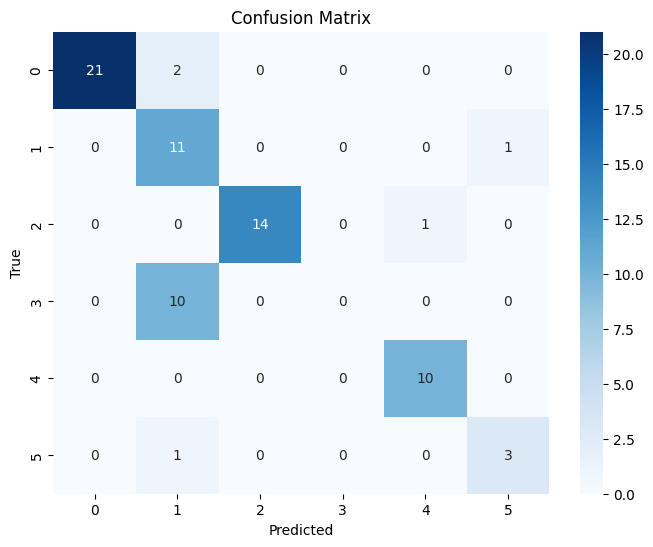

In [47]:
roc_auc = roc_auc_score(
    y_test,
    y_proba,
    multi_class='ovr'
)

print("ROC-AUC:", roc_auc)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

10. Interpretação

In [ ]:
result = permutation_importance(
    pipe, # pipeline treinado
    X_test, # conjunto de teste
    y_test, # rótulos do conjunto de teste
    n_repeats=10, # número de repetições para o cálculo da importância
    random_state=config["data"]["random_state"] # semente para reprodutibilidade
)

X_test_selected = pipe.named_steps['selector'].transform(
    pipe.named_steps['scaler'].transform(X_test)
)

result = permutation_importance(
    pipe.named_steps['clf'],
    X_test_selected,
    y_test,
    n_repeats=10,
    random_state=config["data"]["random_state"]
)
selected_names = X.columns[
    pipe.named_steps['selector'].get_support()
]

perm_df = pd.Series(
    result.importances_mean,
    index=selected_names
).sort_values()


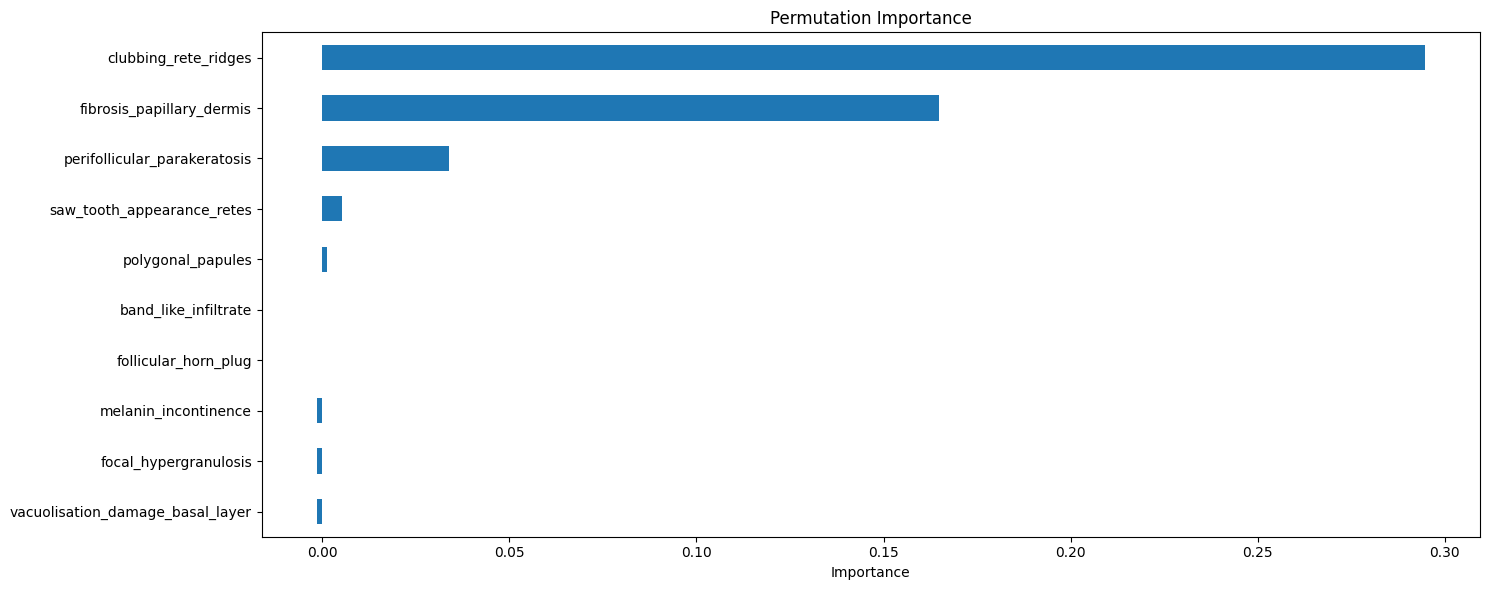

In [49]:
plt.figure(figsize=(15,6))
perm_df.plot(kind='barh')

plt.title('Permutation Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(pipe, "dermatology_model.pkl")
print("Model saved as dermatology_model.pkl")

Model saved as dermatology_model.pkl


In [51]:
wandb.init(
    project="mlops-project-dermatology",
    job_type="train",
    name="logistic_regression_pipeline"
)

wandb.log({
    "accuracy": accuracy_score(y_test, y_pred),
    "roc_auc": roc_auc
})

wandb.finish()

accuracy,▁
roc_auc,▁
accuracy,0.7973
roc_auc,0.96092
